In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sweetviz as sv
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import gc

In [ ]:
# EDA
train = pd.read_csv('../data/train.csv')
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [ ]:
test = pd.read_csv('../data/test.csv')
print(test.head())

       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  630000      Silt     6.36          26.19            0.59   
1  630001      Clay     5.87           9.88            1.18   
2  630002     Sandy     6.22          26.55            0.96   
3  630003      Clay     7.68          53.58            0.83   
4  630004     Loamy     5.23          59.02            0.54   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     2.81          17.83     30.24      1533.38   
1                     3.26          21.18     78.07       576.05   
2                     0.85          26.87     60.35       545.30   
3                     0.55          41.74     36.05      1211.03   
4                     2.11          41.08     52.47      1321.91   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0            5.40            3.00     Maize            Sowing    Rabi   
1            7.22           15.88    Cotton            Sowing    R

In [6]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'
]
NUM_COLS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'
]
TARGET = 'Irrigation_Need'
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (630000, 21)  |  Test: (270000, 20)


Missing Values & Data Types

In [7]:
print('=== dtypes ===')
print(train.dtypes)
print('\n=== Missing values (train) ===')
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None')
print('\n=== Missing values (test) ===')
missing_t = test.isnull().sum()
print(missing_t[missing_t > 0] if missing_t.sum() > 0 else 'None')

=== dtypes ===
id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

=== Missing values (train) ===
None

=== Missing values (test) ===
None


Target Distribution

Class distribution:
  Low        369,917  (58.7%)
  Medium     239,074  (37.9%)
  High        21,009  (3.3%)


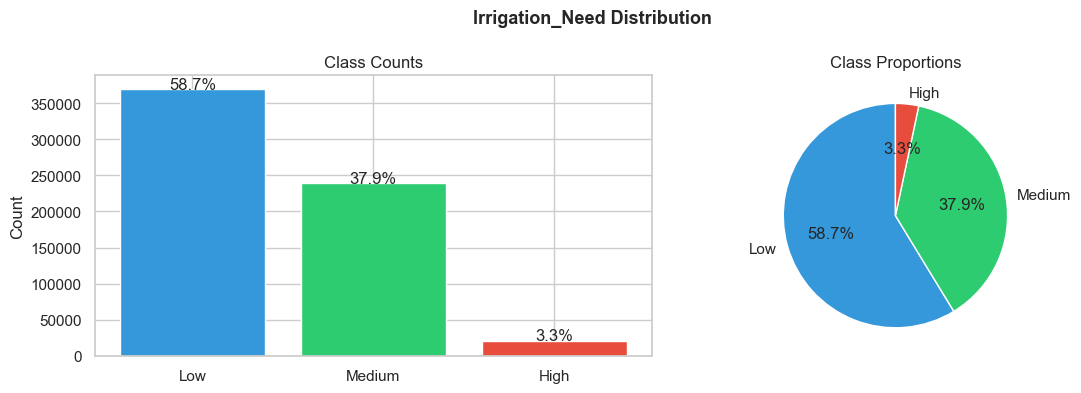

In [8]:
order   = ['Low', 'Medium', 'High']
colors  = ['#3498db', '#2ecc71', '#e74c3c']
counts  = train[TARGET].value_counts()
pcts    = train[TARGET].value_counts(normalize=True) * 100

print('Class distribution:')
for c in order:
    print(f'  {c:<10} {counts.get(c, 0):>7,}  ({pcts.get(c, 0):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(order, [counts.get(c, 0) for c in order], color=colors)
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Count')
for i, c in enumerate(order):
    axes[0].text(i, counts.get(c, 0) + 200, f'{pcts.get(c, 0):.1f}%', ha='center')

axes[1].pie([counts.get(c, 0) for c in order], labels=order,
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportions')

plt.suptitle('Irrigation_Need Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
"""## Sweetviz Report, be sure to account for cateogorical target """
for cls in ['Low', 'Medium', 'High']:
    df = train.copy()
    df[f'is_{cls}'] = (df['Irrigation_Need'] == cls).astype(int)
    report = sv.analyze(df, target_feat=f'is_{cls}')
    report.show_html(f'irrigation_report_{cls}.html')



                                             |          | [  0%]   00:00 -> (? left)

Report irrigation_report_Low.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |          | [  0%]   00:00 -> (? left)

Report irrigation_report_Medium.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |          | [  0%]   00:00 -> (? left)

Report irrigation_report_High.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Numerical Feature Summary

In [12]:
train[NUM_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.48,0.92,4.80,5.69,6.44,7.27,8.20
Soil_Moisture,630000.0,37.30,16.38,8.00,23.34,37.75,51.27,64.99
Organic_Carbon,630000.0,0.92,0.37,0.30,0.61,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.74,0.95,0.10,0.93,1.74,2.58,3.50
Temperature_C,630000.0,27.00,8.62,12.00,19.52,26.96,34.54,42.00
Humidity,630000.0,61.56,19.71,25.00,45.39,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.21,612.99,0.38,954.57,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.51,2.00,4.00,5.76,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.38,5.69,0.50,5.28,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.52,4.22,0.30,3.88,7.38,11.14,15.00


Numerical Features by Target Class (Box Plots)

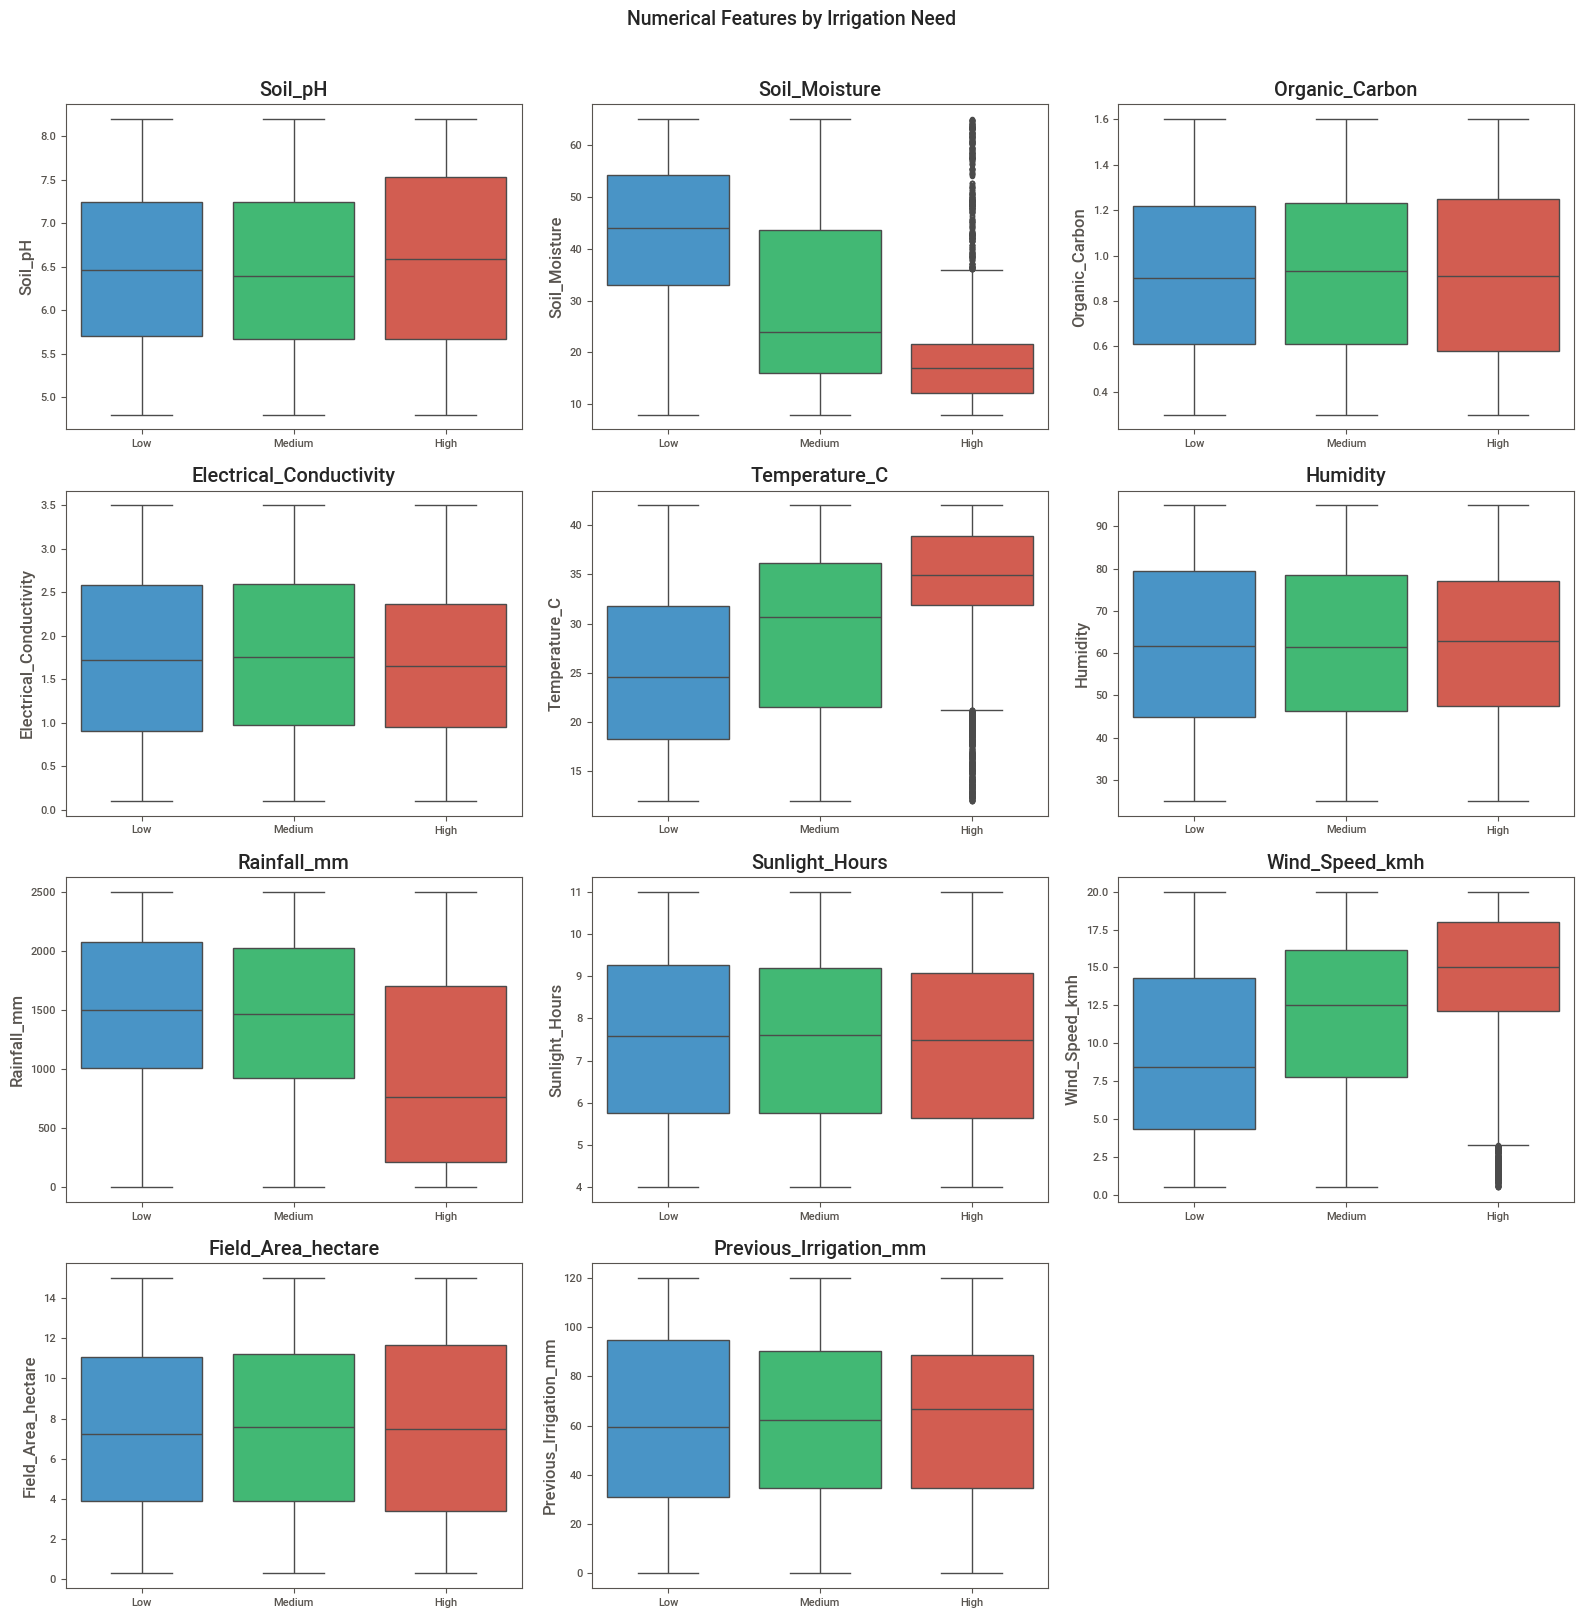

In [13]:
palette = {'Low': '#3498db', 'Medium': '#2ecc71', 'High': '#e74c3c'}
n_cols  = 3
n_rows  = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=train, x=TARGET, y=col, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Irrigation Need', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Categorical Features vs Target

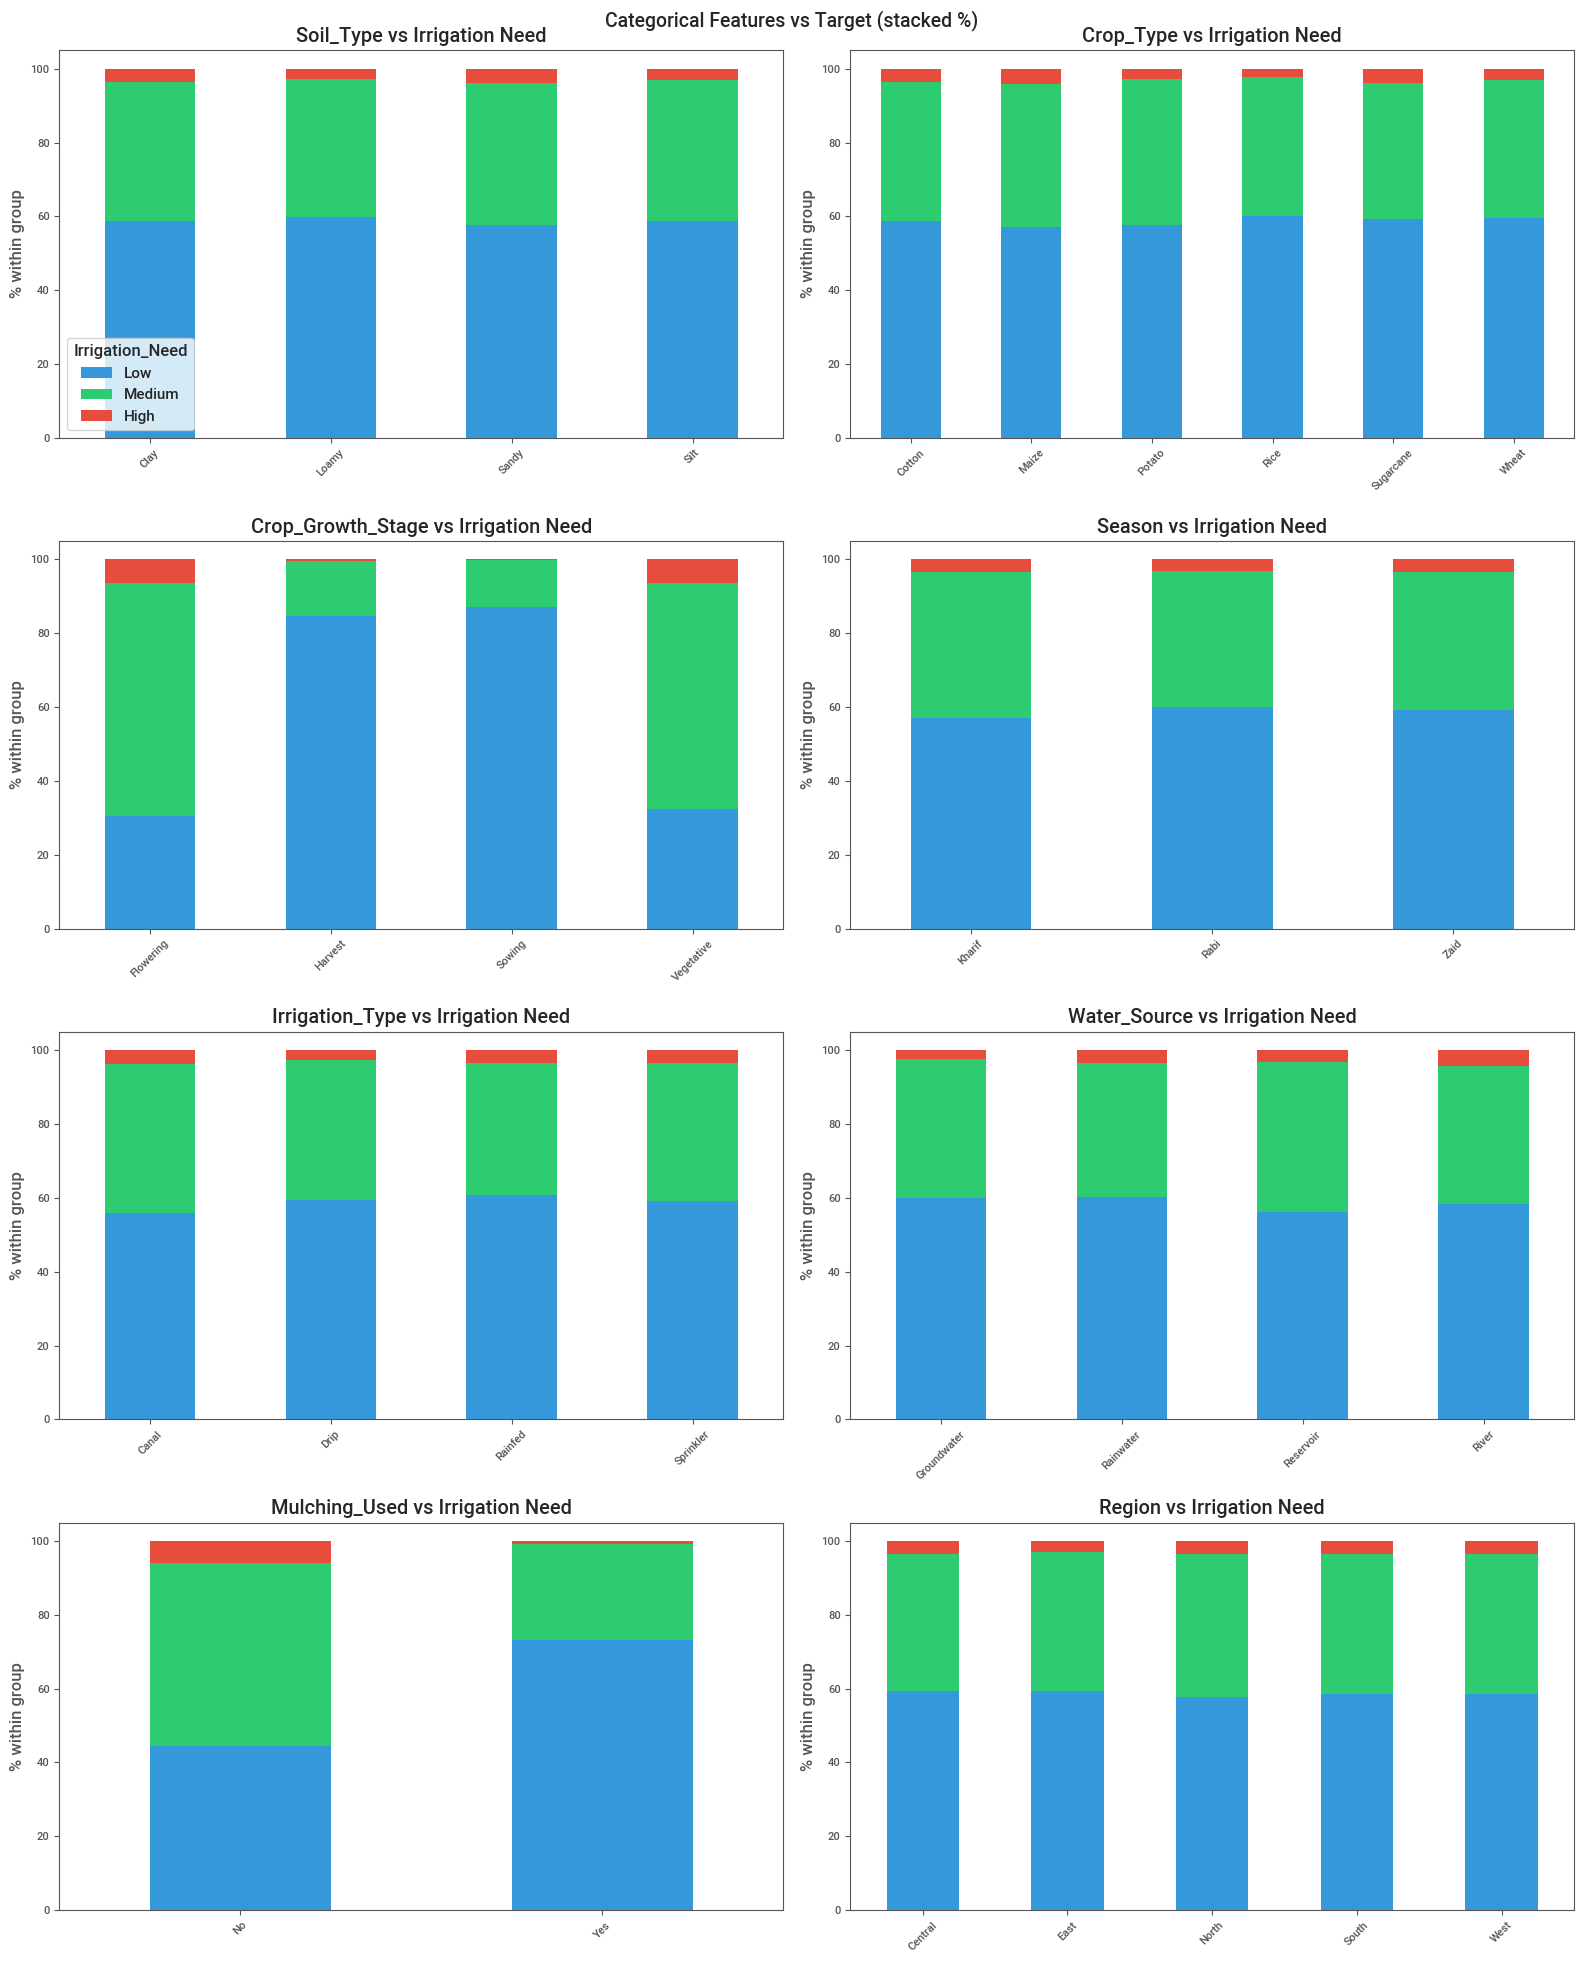

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(train[col], train[TARGET], normalize='index') * 100
    ct = ct.reindex(columns=order, fill_value=0)
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=colors, legend=(i == 0))
    axes[i].set_title(f'{col} vs Irrigation Need')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Target (stacked %)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Domain Threshold Analysis

The reference notebooks identify four binary thresholds that are highly predictive:
- `Soil_Moisture < 25` → higher irrigation need
- `Rainfall_mm < 300` → higher irrigation need
- `Temperature_C > 30` → higher irrigation need
- `Wind_Speed_kmh > 10` → higher irrigation need

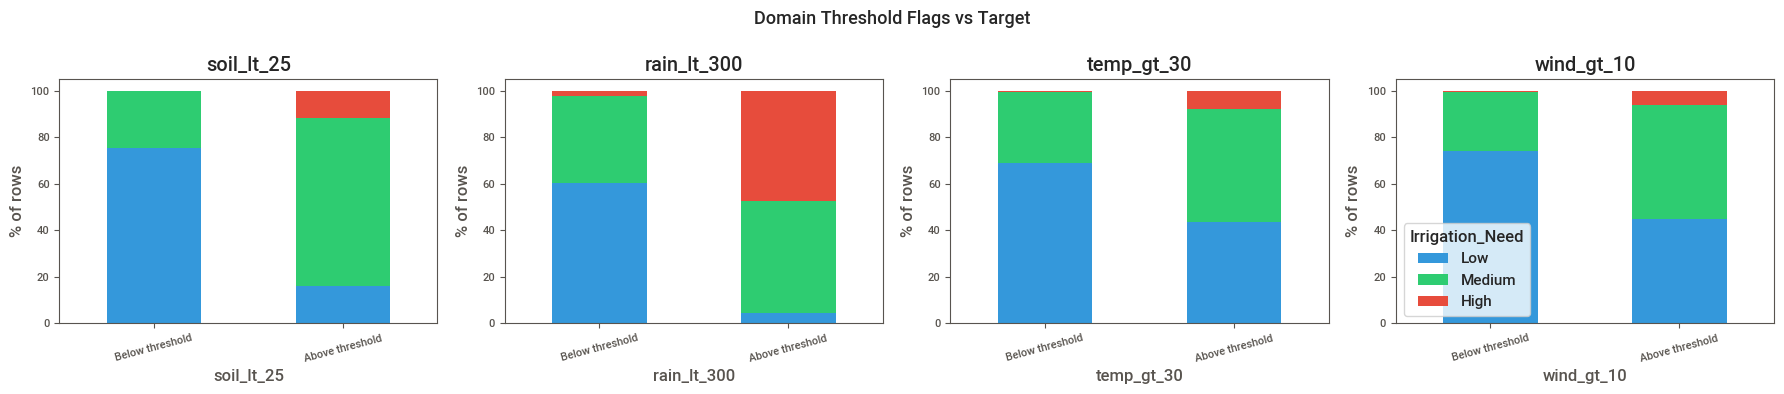

In [15]:
thresh_df = train.copy()
thresh_df['soil_lt_25']  = (thresh_df['Soil_Moisture']  < 25).astype(int)
thresh_df['rain_lt_300'] = (thresh_df['Rainfall_mm']    < 300).astype(int)
thresh_df['temp_gt_30']  = (thresh_df['Temperature_C']  > 30).astype(int)
thresh_df['wind_gt_10']  = (thresh_df['Wind_Speed_kmh'] > 10).astype(int)

flag_cols = ['soil_lt_25', 'rain_lt_300', 'temp_gt_30', 'wind_gt_10']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(flag_cols):
    ct = pd.crosstab(thresh_df[col], thresh_df[TARGET], normalize='index') * 100
    ct = ct.reindex(columns=order, fill_value=0)
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=colors, legend=(i == 3))
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Below threshold', 'Above threshold'], rotation=15)
    axes[i].set_ylabel('% of rows')

plt.suptitle('Domain Threshold Flags vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap

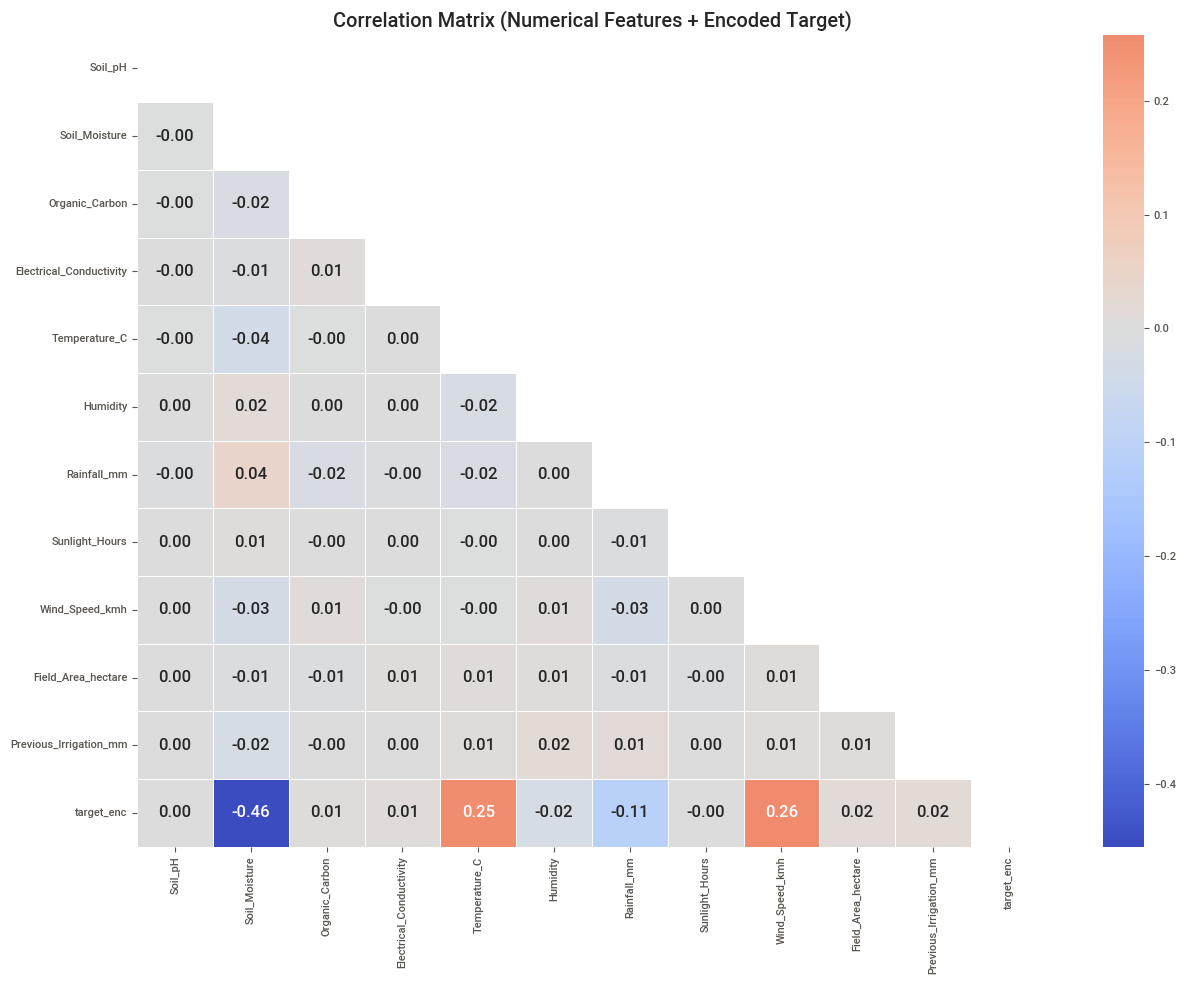

Correlations with target (sorted):
Soil_Moisture             -0.455
Wind_Speed_kmh             0.258
Temperature_C              0.253
Rainfall_mm               -0.111
Humidity                  -0.022
Previous_Irrigation_mm     0.020
Field_Area_hectare         0.018
Electrical_Conductivity    0.011
Organic_Carbon             0.006
Sunlight_Hours            -0.000
Soil_pH                    0.000
Name: target_enc, dtype: float64


In [16]:
corr_df = train[NUM_COLS].copy()
corr_df['target_enc'] = train[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix (Numerical Features + Encoded Target)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlations with target (sorted):')
print(corr_df.corr()['target_enc'].drop('target_enc').sort_values(key=abs, ascending=False).round(3))

## KDE: Soil Moisture & Rainfall by Class

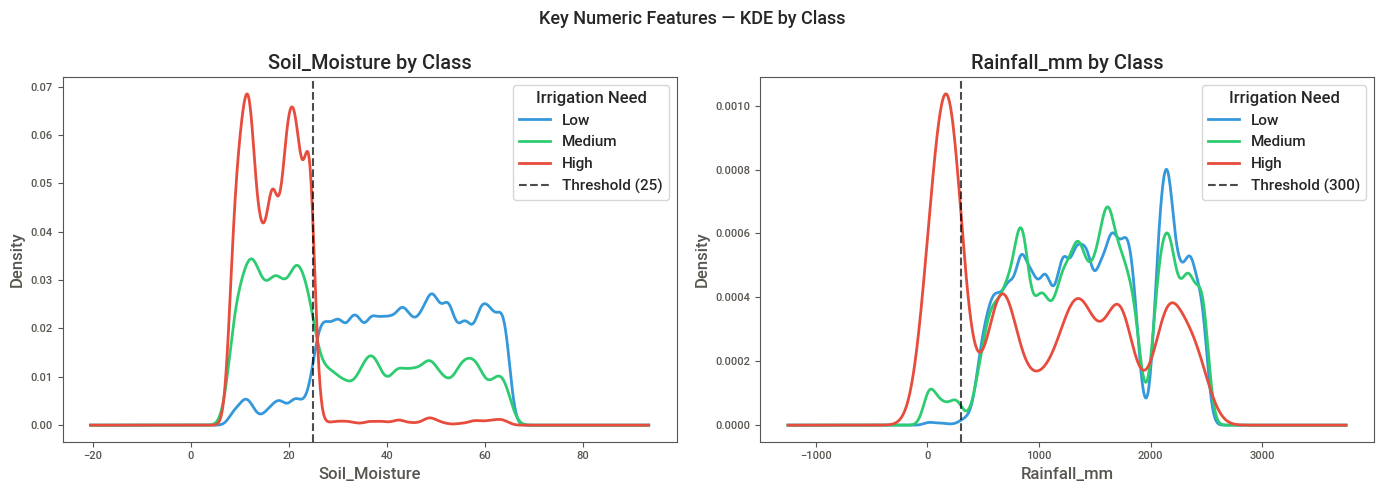

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, thresh) in zip(axes, [('Soil_Moisture', 25), ('Rainfall_mm', 300)]):
    for cls, clr in zip(order, colors):
        train[train[TARGET] == cls][col].plot.kde(ax=ax, label=cls, color=clr, linewidth=2)
    ax.axvline(thresh, color='black', linestyle='--', alpha=0.7, label=f'Threshold ({thresh})')
    ax.set_title(f'{col} by Class')
    ax.set_xlabel(col)
    ax.legend(title='Irrigation Need')

plt.suptitle('Key Numeric Features — KDE by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Train vs Test Distributions

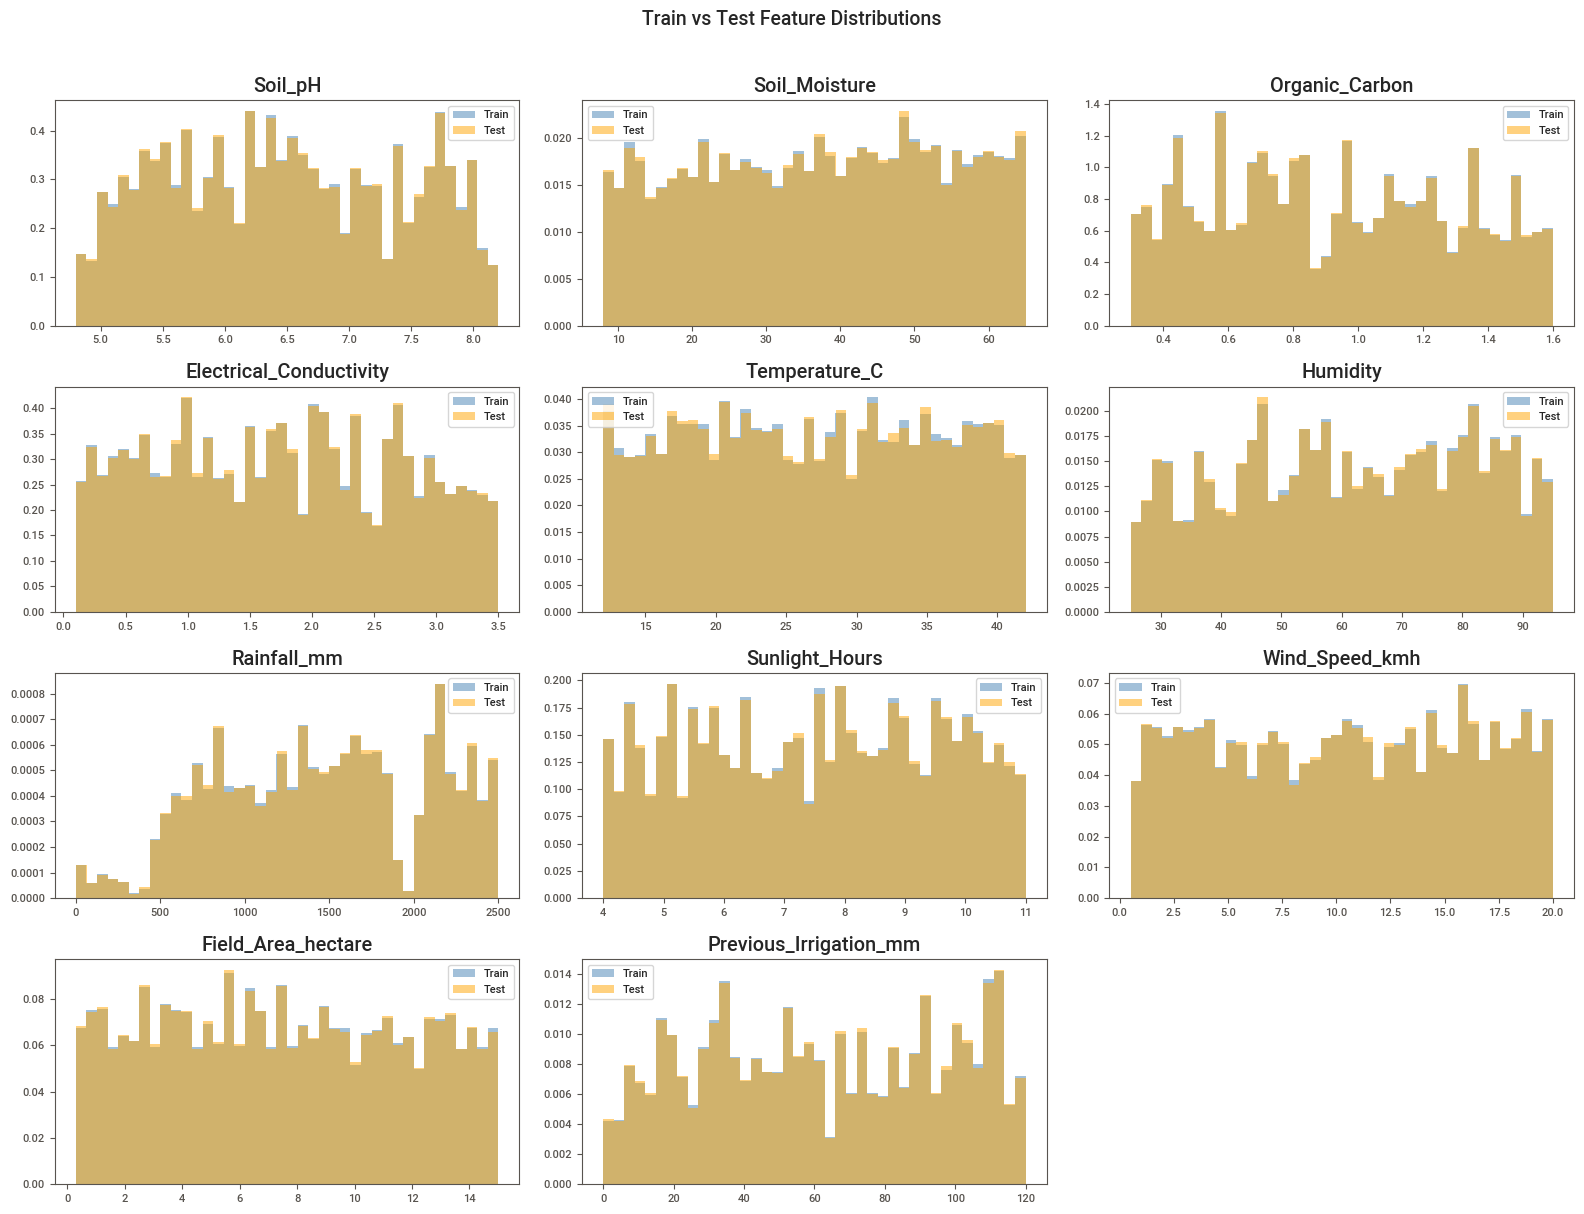

In [18]:
n_cols = 3
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].hist(train[col].dropna(), bins=40, alpha=0.5, label='Train',
                 color='steelblue', density=True)
    axes[i].hist(test[col].dropna(),  bins=40, alpha=0.5, label='Test',
                 color='orange', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Train vs Test Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## EDA Summary

**Dataset size:** Train has 630,000 rows × 21 columns; test has 270,000 rows × 20 columns (no target). No missing values in either split.

**Class imbalance:** The target is heavily imbalanced, with the Low class containing 58.7% (369,917), Medium 37.9% (239,074), and High 3.3% (21,009). High is severely underrepresented as further shown in the sweetviz visuals. Since the metric is balanced accuracy, class weighting or threshold optimization will be critical.

**Strongest numeric predictors (by correlation with encoded target):**
- `Soil_Moisture` (r = -0.455) — by far the strongest signal; lower moisture --> higher irrigation need
- `Wind_Speed_kmh` (r = 0.258) — higher wind --> higher need
- `Temperature_C` (r = 0.253) — higher temp --> higher need
- `Rainfall_mm` (r = -0.111) — more rain --> lower need
- All other numeric features (`Humidity`, `Previous_Irrigation_mm`, `Field_Area_hectare`, `Electrical_Conductivity`, `Organic_Carbon`, `Sunlight_Hours`, `Soil_pH`) have near-zero correlation with the target on their own.

**Domain thresholds:** The binary flags `soil_lt_25`, `rain_lt_300`, `temp_gt_30`, and `wind_gt_10` cleanly separate classes --> rows above the threshold skew strongly toward High, rows below toward Low. These are the most powerful engineered features.

**Strongest categorical predictors:** `Crop_Growth_Stage` and `Mulching_Used` are highly predictive. Harvest and Sowing stages are associated with Low need; Flowering and Vegetative with High. Mulching=Yes reduces irrigation need.

**Feature engineering plan:** Binary threshold flags, composite `magic_score`, ET proxy, soil health index, and signed threshold distances are all shown to be effective in the reference notebooks. The near-zero raw correlations for most features suggest that interaction variables and nonlinear combinations will be important.

## Modeling

- **Bagging:** Random Forest
- **Boosting:** XGBoost 
Both use 5-fold stratified cross-validation. 

Metric: **balanced accuracy** 

### Feature Engineering & Preprocessing

In [20]:
SEED = 42
N_FOLDS = 5

def add_features(df):
    """Domain-driven feature engineering based on EDA findings."""
    df = df.copy()
    # Binary threshold flags — strongest signals from EDA
    df['soil_lt_25']  = (df['Soil_Moisture']  < 25).astype(int)
    df['rain_lt_300'] = (df['Rainfall_mm']    < 300).astype(int)
    df['temp_gt_30']  = (df['Temperature_C']  > 30).astype(int)
    df['wind_gt_10']  = (df['Wind_Speed_kmh'] > 10).astype(int)
    df['is_harvest']  = (df['Crop_Growth_Stage'] == 'Harvest').astype(int)
    df['is_sowing']   = (df['Crop_Growth_Stage'] == 'Sowing').astype(int)
    df['mulch_yes']   = (df['Mulching_Used'] == 'Yes').astype(int)
    # Composite score: high values → High irrigation need
    df['magic_score'] = (2*df['soil_lt_25'] + 2*df['rain_lt_300']
                         + df['temp_gt_30'] + df['wind_gt_10']
                         - 2*df['is_harvest'] - 2*df['is_sowing'] - df['mulch_yes'])
    # Signed distances from thresholds
    df['soil_dist_25']  = df['Soil_Moisture']  - 25
    df['rain_dist_300'] = df['Rainfall_mm']    - 300
    df['temp_dist_30']  = df['Temperature_C']  - 30
    df['wind_dist_10']  = df['Wind_Speed_kmh'] - 10
    # ET proxy and water balance
    df['ET_Proxy']          = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)
    df['Total_Water_Input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['Heat_Stress']       = df['Temperature_C'] * (100 - df['Humidity']) / 100
    df['Dryness_Index']     = df['Temperature_C'] * df['Sunlight_Hours'] / (df['Rainfall_mm'] + 1)
    df['Soil_Health']       = df['Organic_Carbon'] * df['Soil_Moisture'] / (df['Electrical_Conductivity'] + 0.1)
    return df

train_fe = add_features(train)
test_fe  = add_features(test)

# Label-encode categoricals
CAT_COLS = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_fe[col].astype(str), test_fe[col].astype(str)])
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col]  = le.transform(test_fe[col].astype(str))

TARGET_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
INV_MAP    = {0: 'Low', 1: 'Medium', 2: 'High'}

y = train_fe['Irrigation_Need'].map(TARGET_MAP).values

feature_cols = [c for c in train_fe.columns if c not in ['id', 'Irrigation_Need']]
X      = train_fe[feature_cols].values
X_test = test_fe[[c for c in feature_cols if c in test_fe.columns]].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print(f'Features: {len(feature_cols)}')
print(f'Train: {X.shape}  |  Test: {X_test.shape}')

Features: 36
Train: (630000, 36)  |  Test: (270000, 36)


### Bagging: Random Forest

In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',   # handles the 3.3% High class
    n_jobs=-1,
    random_state=SEED
)

rf_oof   = np.zeros((len(X), 3))
rf_test  = np.zeros((len(X_test), 3))
rf_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    rf.fit(X[tr_idx], y[tr_idx])
    rf_oof[val_idx] = rf.predict_proba(X[val_idx])
    rf_test += rf.predict_proba(X_test) / N_FOLDS
    score = balanced_accuracy_score(y[val_idx], rf_oof[val_idx].argmax(1))
    rf_scores.append(score)
    print(f'  RF Fold {fold+1}: {score:.5f}')
    gc.collect()

rf_oof_score = balanced_accuracy_score(y, rf_oof.argmax(1))
print(f'\nRandom Forest OOF Balanced Accuracy: {rf_oof_score:.5f}')

  RF Fold 1: 0.96381
  RF Fold 2: 0.96518
  RF Fold 3: 0.96528
  RF Fold 4: 0.96393
  RF Fold 5: 0.96445

Random Forest OOF Balanced Accuracy: 0.96453


### Boosting: XGBoost

In [ ]:
sample_weights = compute_sample_weight('balanced', y)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

xgb_oof   = np.zeros((len(X), 3))
xgb_test  = np.zeros((len(X_test), 3))
xgb_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    xgb.fit(
        X[tr_idx], y[tr_idx],
        sample_weight=sample_weights[tr_idx],
        eval_set=[(X[val_idx], y[val_idx])],
        verbose=False
    )
    xgb_oof[val_idx] = xgb.predict_proba(X[val_idx])
    xgb_test += xgb.predict_proba(X_test) / N_FOLDS
    score = balanced_accuracy_score(y[val_idx], xgb_oof[val_idx].argmax(1))
    xgb_scores.append(score)
    print(f'  XGB Fold {fold+1}: {score:.5f}')
    gc.collect()

xgb_oof_score = balanced_accuracy_score(y, xgb_oof.argmax(1))
print(f'\nXGBoost OOF Balanced Accuracy: {xgb_oof_score:.5f}')

  XGB Fold 1: 0.96978
  XGB Fold 2: 0.97134
  XGB Fold 3: 0.97225
  XGB Fold 4: 0.97022
  XGB Fold 5: 0.97138

XGBoost OOF Balanced Accuracy: 0.97099


### Results Comparison

=== Cross-Validation Results ===
Random Forest  — Mean BA: 0.96453  Std: 0.00061
XGBoost        — Mean BA: 0.97099  Std: 0.00088


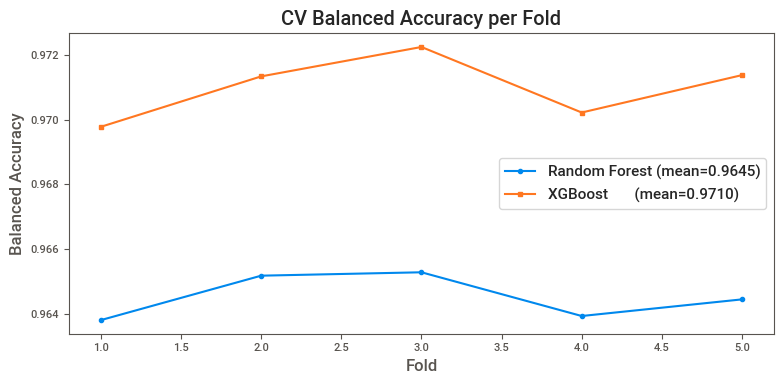

In [23]:
print('=== Cross-Validation Results ===')
print(f'Random Forest  — Mean BA: {np.mean(rf_scores):.5f}  Std: {np.std(rf_scores):.5f}')
print(f'XGBoost        — Mean BA: {np.mean(xgb_scores):.5f}  Std: {np.std(xgb_scores):.5f}')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(N_FOLDS)
ax.plot(x + 1, rf_scores,  marker='o', label=f'Random Forest (mean={np.mean(rf_scores):.4f})')
ax.plot(x + 1, xgb_scores, marker='s', label=f'XGBoost       (mean={np.mean(xgb_scores):.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('CV Balanced Accuracy per Fold')
ax.legend()
plt.tight_layout()
plt.show()

### Generate Submissions

In [24]:
# Random Forest submission
rf_preds = rf_test.argmax(axis=1)
rf_sub = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': [INV_MAP[p] for p in rf_preds]
})
rf_sub.to_csv('submission_rf.csv', index=False)
print('submission_rf.csv saved')
print(rf_sub['Irrigation_Need'].value_counts())

print()

# XGBoost submission
xgb_preds = xgb_test.argmax(axis=1)
xgb_sub = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': [INV_MAP[p] for p in xgb_preds]
})
xgb_sub.to_csv('submission_xgb.csv', index=False)
print('submission_xgb.csv saved')
print(xgb_sub['Irrigation_Need'].value_counts())

submission_rf.csv saved
Irrigation_Need
Low       159892
Medium    101335
High        8773
Name: count, dtype: int64

submission_xgb.csv saved
Irrigation_Need
Low       159942
Medium    100502
High        9556
Name: count, dtype: int64


### Modeling Summary

**Random Forest (Bagging):** Built 300 trees, used `class_weight='balanced'` to handle the rarer High class (3.3%). Achieved OOF balanced accuracy of **0.96453** (fold scores: 0.96381, 0.96518, 0.96528, 0.96393, 0.96445), showing very consistent performance across folds.

**XGBoost (Boosting):** Built 200 trees sequentially on the same sample, each correcting the residuals of the previous. Used `compute_sample_weight('balanced')` to account for class imbalance. Achieved OOF balanced accuracy of **0.97099** (fold scores: 0.96978, 0.97134, 0.97225, 0.97022, 0.97138), outperforming Random Forest by ~0.007.

**Comparison:** XGBoost outperforms Random Forest on this dataset. Both models are very stable across folds, which is a good sign. The boosting approach's sequential error-correction is better suited to this problem than bagging's variance reduction, probably because boosting can learn threshold rules more precisely. 